/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride
/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


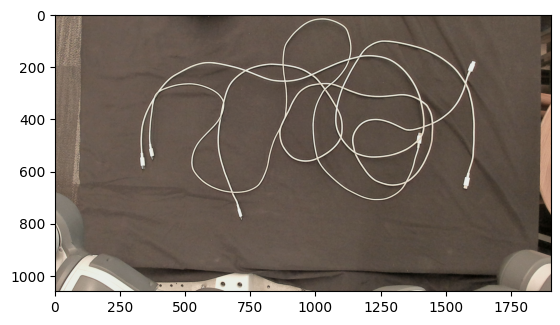

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# from yumi_jacobi.interface import Interface
from decluttering.scripts.brio.brio_sensor import BRIOSensor
from decluttering.src.divergence_utils.divergence import get_all_div_points
from decluttering.data.utils.endpoint_detector_dataloader import EndpointDataloader
from decluttering.src.motion_jacobi import get_poi_and_vec_for_push
from decluttering.src.motion_jacobi import perform_push_through
from decluttering.src.motion_jacobi import get_push_coords

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
path = '/home/justinyu/vsumedh/data/raw_images/parallel-20240711-133357.png' # array contains Nans
# path = '/home/justinyu/vsumedh/data/raw_images/parallel-20240711-133151.png'
im_frame2 = Image.open(path)
np_frame2 = np.array(im_frame2)

# remove alpha channel
# np_frame2 = np_frame2[0:650, :, :3]
# tt_frame2 = torch.tensor(np_frame2).to(torch.uint8)
plt.imshow(np_frame2)

# dim = (1060, 1904, 3)
# img = cam.read()
# img_down = cv2.resize(img, (img.shape[1]//2, img.shape[0]//2)) # dim

endpoint_model = EndpointDataloader()
endpoints = endpoint_model.predict(np_frame2)['endpoints']




NOTICE: Using divergence.py

Autoregressive Tracer Using GPU
Autoregressive Tracer Using GPU
Time for analytic tracer: 0.1224517822265625
Beginning trace with 4 start points


Elapsed time for tracing:  1.7888290882110596
Time for analytic tracer: 0.15625834465026855
Beginning trace with 4 start points
Elapsed time for tracing:  0.7016274929046631
Time for analytic tracer: 0.15033340454101562
Beginning trace with 4 start points
Elapsed time for tracing:  1.8349177837371826
Time for analytic tracer: 0.19222068786621094
Beginning trace with 4 start points


/home/justinyu/multicable-decluttering/decluttering/data/tracer/tusk_pipeline/tracer.py:260: RuntimeWarning: invalid value encountered in double_scalars
  mean_x = np.sum(x_flat * data_flat) / total_weight
/home/justinyu/multicable-decluttering/decluttering/data/tracer/tusk_pipeline/tracer.py:261: RuntimeWarning: invalid value encountered in double_scalars
  mean_y = np.sum(y_flat * data_flat) / total_weight


ValueError: array must not contain infs or NaNs

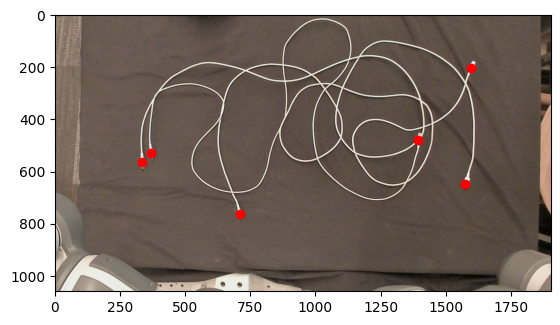

In [2]:

plt.imshow(np_frame2)
plt.scatter(endpoints[:, 1], endpoints[:, 0], c='r')
get_all_div_points(np_frame2, endpoints)

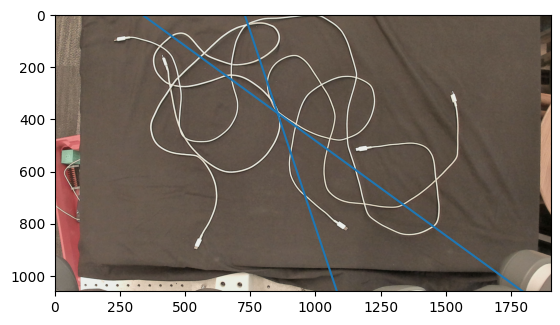

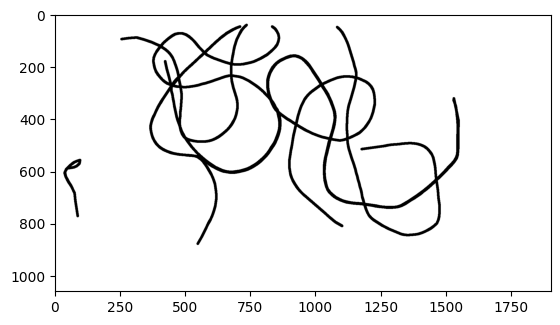

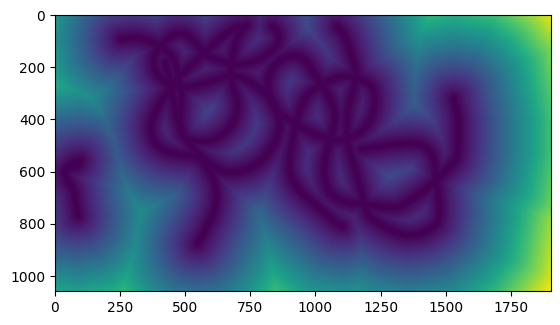

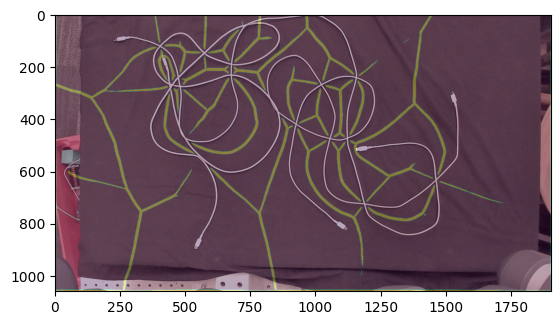

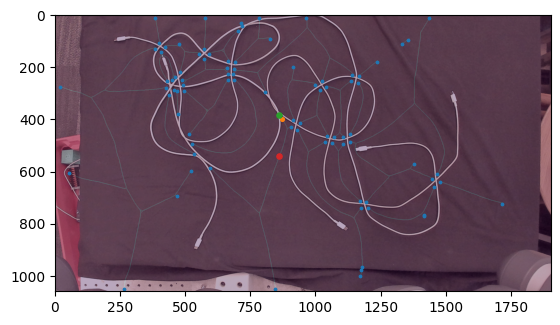

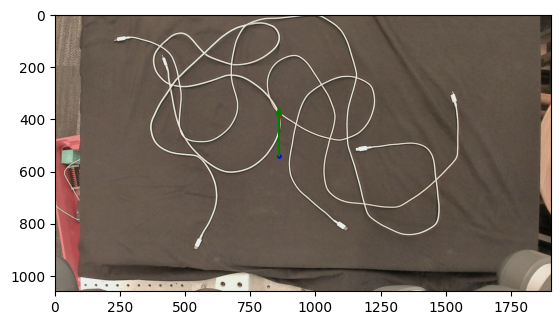

In [3]:
# print(output['div_points'].shape)
# print(output['div_points'].dtype)
# print(np_frame2.shape)
# print(np_frame2.dtype)
# print(np.array(output['trace_list']).shape)
# print(np.array(output['trace_list']).dtype)
# print(type(output['start_idx']))
# print(np.array(output['trace_list'])[0].shape)
poi_trace, cen_poi_vec = get_push_coords(output['div_points'], np_frame2, output['trace_list'], output['start_idx'], output['end_idx'], viz=True)

plt.clf()
plt.imshow(np_frame2)
plt.scatter(poi_trace[0], poi_trace[1], c='r', s=5)
plt.scatter(cen_poi_vec[0], cen_poi_vec[1], c='b', s=5)

plt.arrow(cen_poi_vec[0], cen_poi_vec[1], poi_trace[0]-cen_poi_vec[0], poi_trace[1]-cen_poi_vec[1], width = 2, head_width=20, head_length=30, fc='g', ec='g')

plt.show()

Autoregressive Tracer Using GPU
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  1.0578734874725342


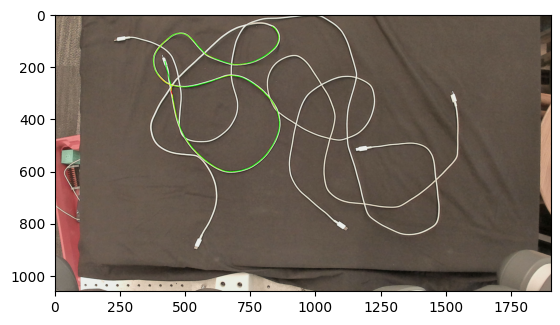

In [4]:
from decluttering.data.utils.tracer_dataloader import TracerDataloader
tracer = TracerDataloader()
analytic_tracer = tracer.analytic_tracer

# for endpt in range(len(endpts)):

# start_time = time.time()
starting_pixels = analytic_tracer.trace(np_frame2, endpoints[0], path_len=3)
# print(f"Time for analytic tracer: {time.time() - start_time}")

out = tracer.predict(np_frame2, np.asarray(starting_pixels[0]).astype(int), endpoints, use_vit=False)

# out.keys()
# print(out['covariances'])

cov_det = out['covariances']

cov_normalized = [(cov - min(cov_det))/(max(cov_det) - min(cov_det)) for cov in cov_det]

plt.imshow(tracer.tracer.visualize_path(np_frame2, np.array(out['trace']), color=cov_normalized))



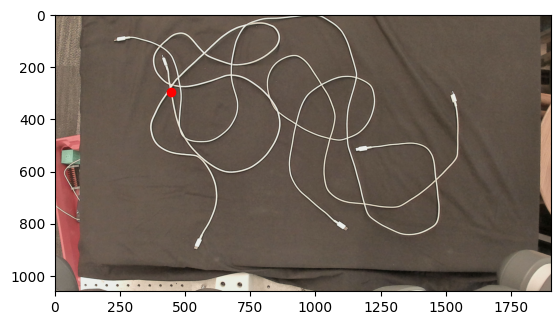

In [5]:
cov_normalized_argmax = np.argmax(cov_normalized)
trace_coord_max_cov = out['trace'][cov_normalized_argmax]
plt.imshow(np_frame2)
plt.scatter(trace_coord_max_cov[1], trace_coord_max_cov[0], c='r')

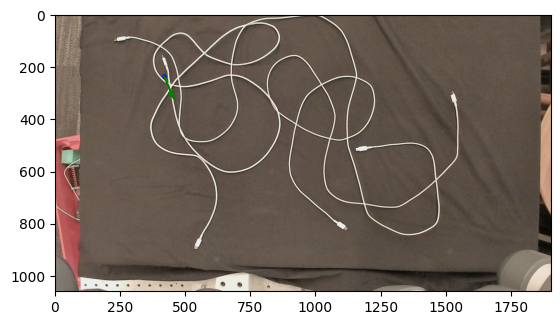

In [6]:
center, vector = get_poi_and_vec_for_push(trace_coord_max_cov, np_frame2, out['trace'])
plt.clf()
plt.imshow(np_frame2)
plt.scatter(center[0], center[1], c='r', s=5)
plt.scatter(center[0]+vector[0], center[1]+vector[1], c='b', s=5)

plt.arrow(center[0]+vector[0], center[1]+vector[1], -vector[0], -vector[1], width = 2, head_width=20, head_length=30, fc='g', ec='g')

plt.show()